In [1]:
from thermoML import main_training
from thermoML import main_test
import pandas as pd
import numpy as np
from thermoML import main_base_test_MT
from thermoML import main_base_test_ST
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics import r2_score

2025-11-06 20:26:59.449908: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-06 20:26:59.451238: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-06 20:26:59.474566: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-06 20:26:59.474921: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-06 20:26:59.854219: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not fin

In [2]:
# approx run-time: a few seconds
path = 'Results/pretrained_weights'
df_test = pd.read_excel('data/Dataset.xlsx', sheet_name='data')
df_test = df_test[['Compounds', 'smiles']][df_test['label'] == 'test'].reset_index(drop = True)
temp_test = pd.read_excel('data/Dataset.xlsx', sheet_name='temp_test')
temp_test = temp_test.iloc[:,1:]

output = main_test(df_test, temp_test, path, helper_output = True, n_models = 20, to_drop = ['Compounds', 'smiles'])

 55%|█████▍    | 130/237 [00:01<00:01, 102.08it/s]

/home/rajabiko/anaconda3/envs/thermo/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/rajabiko/anaconda3/envs/thermo/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/rajabiko/anaconda3/envs/thermo/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/rajabiko/anaconda3/envs/thermo/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 68%|██████▊   | 161/237 [00:02<00:01, 67.70it/s] 

/home/rajabiko/anaconda3/envs/thermo/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/rajabiko/anaconda3/envs/thermo/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


100%|██████████| 237/237 [00:02<00:00, 95.76it/s] 
/home/rajabiko/anaconda3/envs/thermo/lib/python3.9/site-packages/thermoML/utils/eval_model.py:398: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  features = features.applymap(replace_string_with_nan)


8/8 [==============================] - 0s 738us/step


2025-11-06 20:27:07.241104: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-11-06 20:27:07.272848: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1956] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


8/8 [==============================] - 0s 487us/step


#### <b>Multitemperature Base Model Predictions</b>

In [4]:
# approx run-time: a few seconds
df_test = pd.read_excel('data/Dataset.xlsx', sheet_name='data')
df_test = df_test[['Compounds', 'smiles']][df_test['label'] == 'test'].reset_index(drop = True)
temp_test = pd.read_excel('data/Dataset.xlsx', sheet_name='temp_test')
temp_test = temp_test.iloc[:,1:]

model_path = 'Results/base_model'
y_pred_base_avg_temp_all, y_pred_base_std_temp_all, y_pred_base_certainty_temp_all = main_base_test_MT(df_test, temp_test, model_path)

 54%|█████▎    | 127/237 [00:01<00:00, 110.94it/s]

/home/rajabiko/anaconda3/envs/thermo/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 54%|█████▍    | 128/237 [00:02<00:00, 110.94it/s]

/home/rajabiko/anaconda3/envs/thermo/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 81%|████████  | 191/237 [00:02<00:00, 95.84it/s] 

/home/rajabiko/anaconda3/envs/thermo/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/rajabiko/anaconda3/envs/thermo/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/rajabiko/anaconda3/envs/thermo/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/rajabiko/anaconda3/envs/thermo/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


100%|██████████| 237/237 [00:02<00:00, 91.83it/s] 
/home/rajabiko/anaconda3/envs/thermo/lib/python3.9/site-packages/thermoML/utils/Multitemperature_base_model.py:147: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  features = features.applymap(replace_string_with_nan)


38/38 [==============================] - 0s 340us/step


#### <b>Isothermal Base Model Predictions</b>

In [5]:
# approx run-time: a few seconds
df_test = pd.read_excel('data/Dataset.xlsx', sheet_name='data')
df_test = df_test[['Compounds', 'smiles']][df_test['label'] == 'test'].reset_index(drop = True)
temp_test = pd.read_excel('data/Dataset.xlsx', sheet_name='temp_test')
temp_test = temp_test.iloc[:,1:]
    
model_path = 'Results/base_model_singleT'
y_pred_base_avg_temp_all_singleT, y_pred_base_std_temp_all_singleT, y_pred_base_certainty_temp_all_singleT = main_base_test_ST(df_test, temp_test, model_path)

 54%|█████▎    | 127/237 [00:01<00:01, 67.04it/s] 

/home/rajabiko/anaconda3/envs/thermo/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 88%|████████▊ | 208/237 [00:02<00:00, 97.38it/s]

/home/rajabiko/anaconda3/envs/thermo/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/rajabiko/anaconda3/envs/thermo/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/rajabiko/anaconda3/envs/thermo/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/rajabiko/anaconda3/envs/thermo/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/rajabiko/anaconda3/envs/thermo/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwa

100%|██████████| 237/237 [00:02<00:00, 82.62it/s] 
/home/rajabiko/anaconda3/envs/thermo/lib/python3.9/site-packages/thermoML/utils/Isothermal_base_model.py:137: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  features = features.applymap(replace_string_with_nan)


38/38 [==============================] - 0s 354us/step


In [3]:
output

,Compounds,smiles,T1,T2,T3,T4,T5,mu_log_1,mu_log_2,mu_log_3,...,mu_log_5,std_mu_log_1,std_mu_log_2,std_mu_log_3,std_mu_log_4,std_mu_log_5,Ln_A_avg,Ln_A_std,Ea_R_avg,Ea_R_std
0,"1,1,2-Trifluoro-1,2,2-trichloro ethane",FC(F)(Cl)C(F)(Cl)Cl,0.003411,0.003299,0.003193,0.003153,0.003124,-0.728382,-0.847488,-0.958988,...,-1.032768,0.226870,0.222848,0.221871,0.222220,0.222730,-4.339097,0.783445,1058.481323,234.189697
1,"1,2,3,4 Tetra hydronaphthalene",C1CCc2ccccc2C1,0.003354,0.003299,0.003245,0.003193,0.003143,0.271404,0.191963,0.115099,...,-0.031076,0.384463,0.375840,0.367547,0.359568,0.351923,-4.545148,0.297707,1436.055420,174.866287
2,"1,2,3,4-Tetrahydro-2,6-dimethyl-7-octyl naphth...",CCCCCCCCc1cc2CC(C)CCc2cc1C,0.003411,0.003216,0.003002,0.002924,0.002688,3.600638,2.835660,1.996138,...,0.767407,0.286011,0.257085,0.246938,0.249515,0.276354,-9.762843,1.150235,3917.504639,371.700958
3,"1,2-Ethanediol",OCCO,0.003378,0.003205,0.003086,0.002968,0.002914,2.698585,2.294836,2.018193,...,1.616793,0.933991,0.898399,0.874915,0.852279,0.842289,-5.174520,0.742450,2330.438965,296.304657
4,"1,3-Dioxolane",C1COCO1,0.003354,0.003193,0.003096,0.003003,0.002915,0.175572,-0.050518,-0.187562,...,-0.441606,0.237732,0.225315,0.219945,0.216479,0.214771,-4.544431,0.634595,1407.268555,208.637268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,6-Undecanone,CCCCCC(=O)CCCCC,0.003411,0.003354,0.003193,0.003096,0.003012,0.657869,0.564278,0.301439,...,0.004814,0.115245,0.112776,0.106973,0.104353,0.102691,-4.922931,0.282219,1636.011353,93.459892
233,2-Undecanone,CCCCCCCCC(=O)C,0.003411,0.003354,0.003193,0.003095,0.003002,0.373757,0.285909,0.039198,...,-0.254831,0.108218,0.105452,0.099835,0.098129,0.097818,-4.864596,0.376832,1535.623291,120.280937
234,5-Dodecanone,CCCCC(=O)CCCCCCC,0.003411,0.003354,0.003193,0.003077,0.002985,0.868180,0.773414,0.507272,...,0.162237,0.136798,0.133677,0.125712,0.120778,0.117451,-4.782740,0.260888,1656.567017,93.344307
235,2-Dodecanone,CCCCCCCCCCC(=O)C,0.003333,0.003175,0.003077,0.002985,0.002899,0.731082,0.469825,0.309051,...,0.015464,0.151208,0.139774,0.133459,0.128112,0.123667,-4.755318,0.298377,1645.920166,113.381058


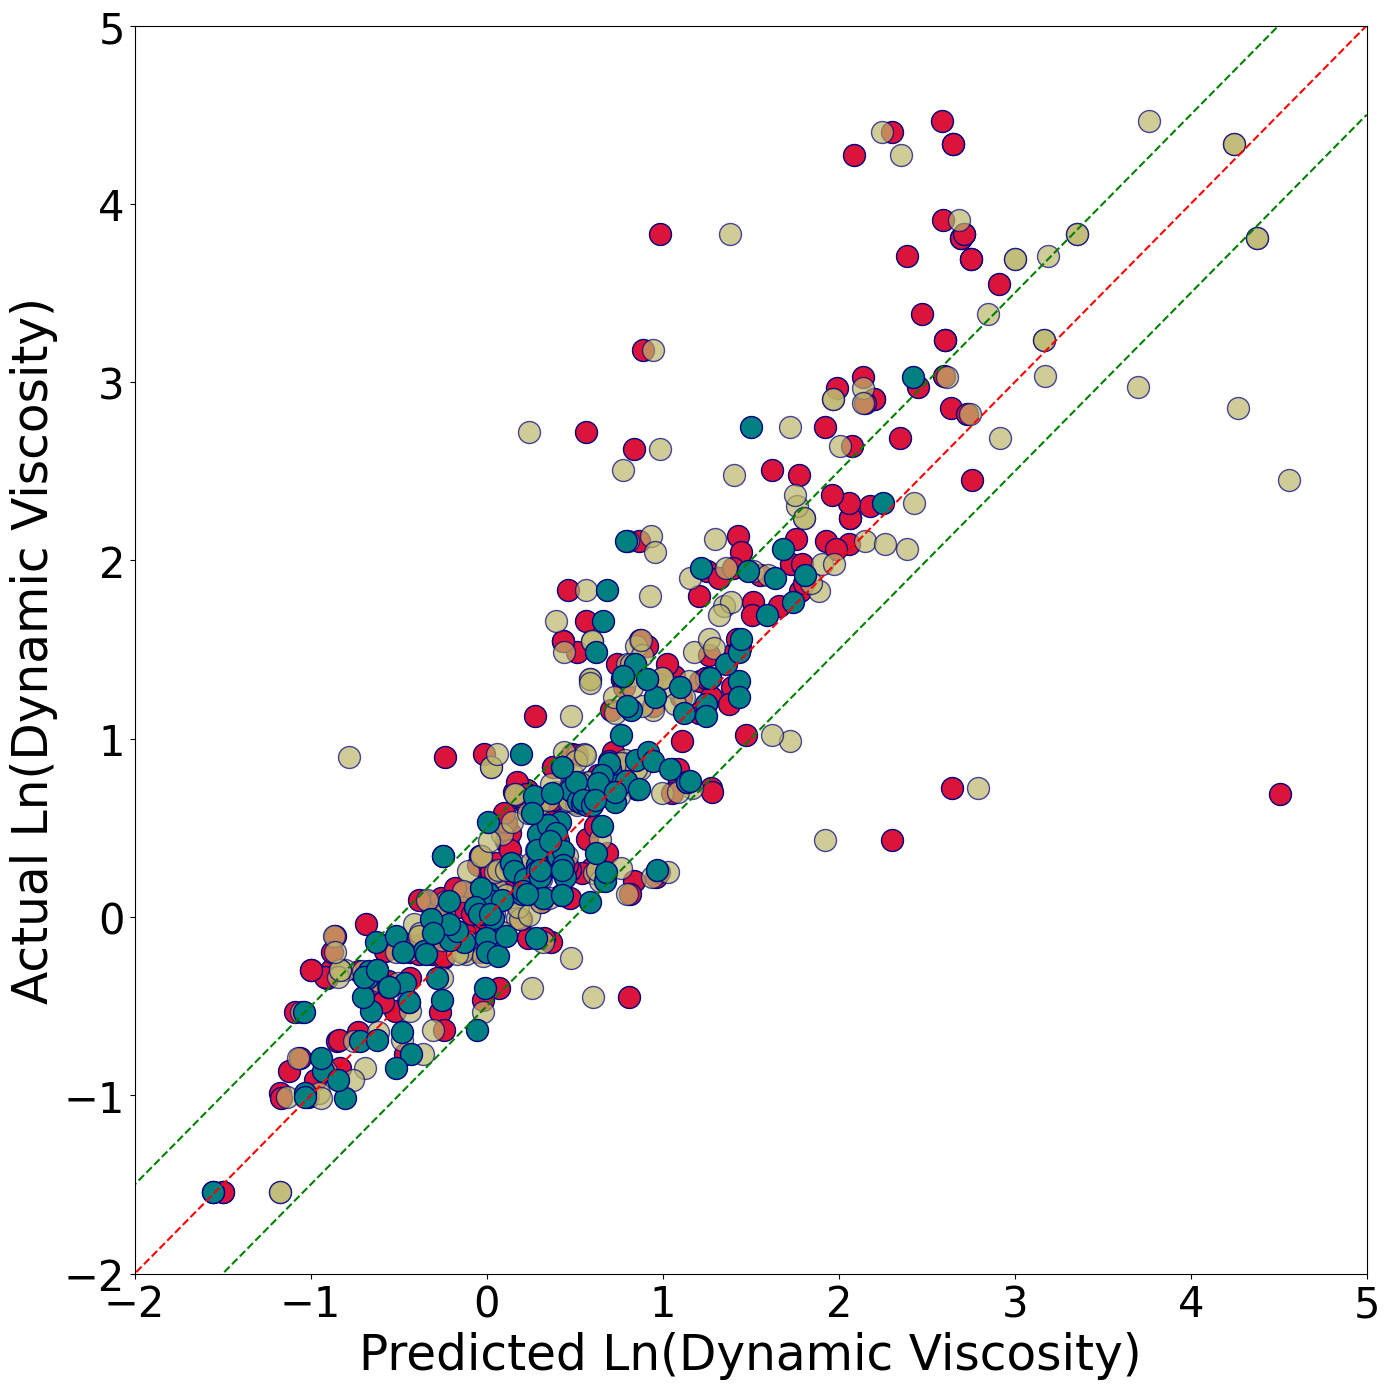

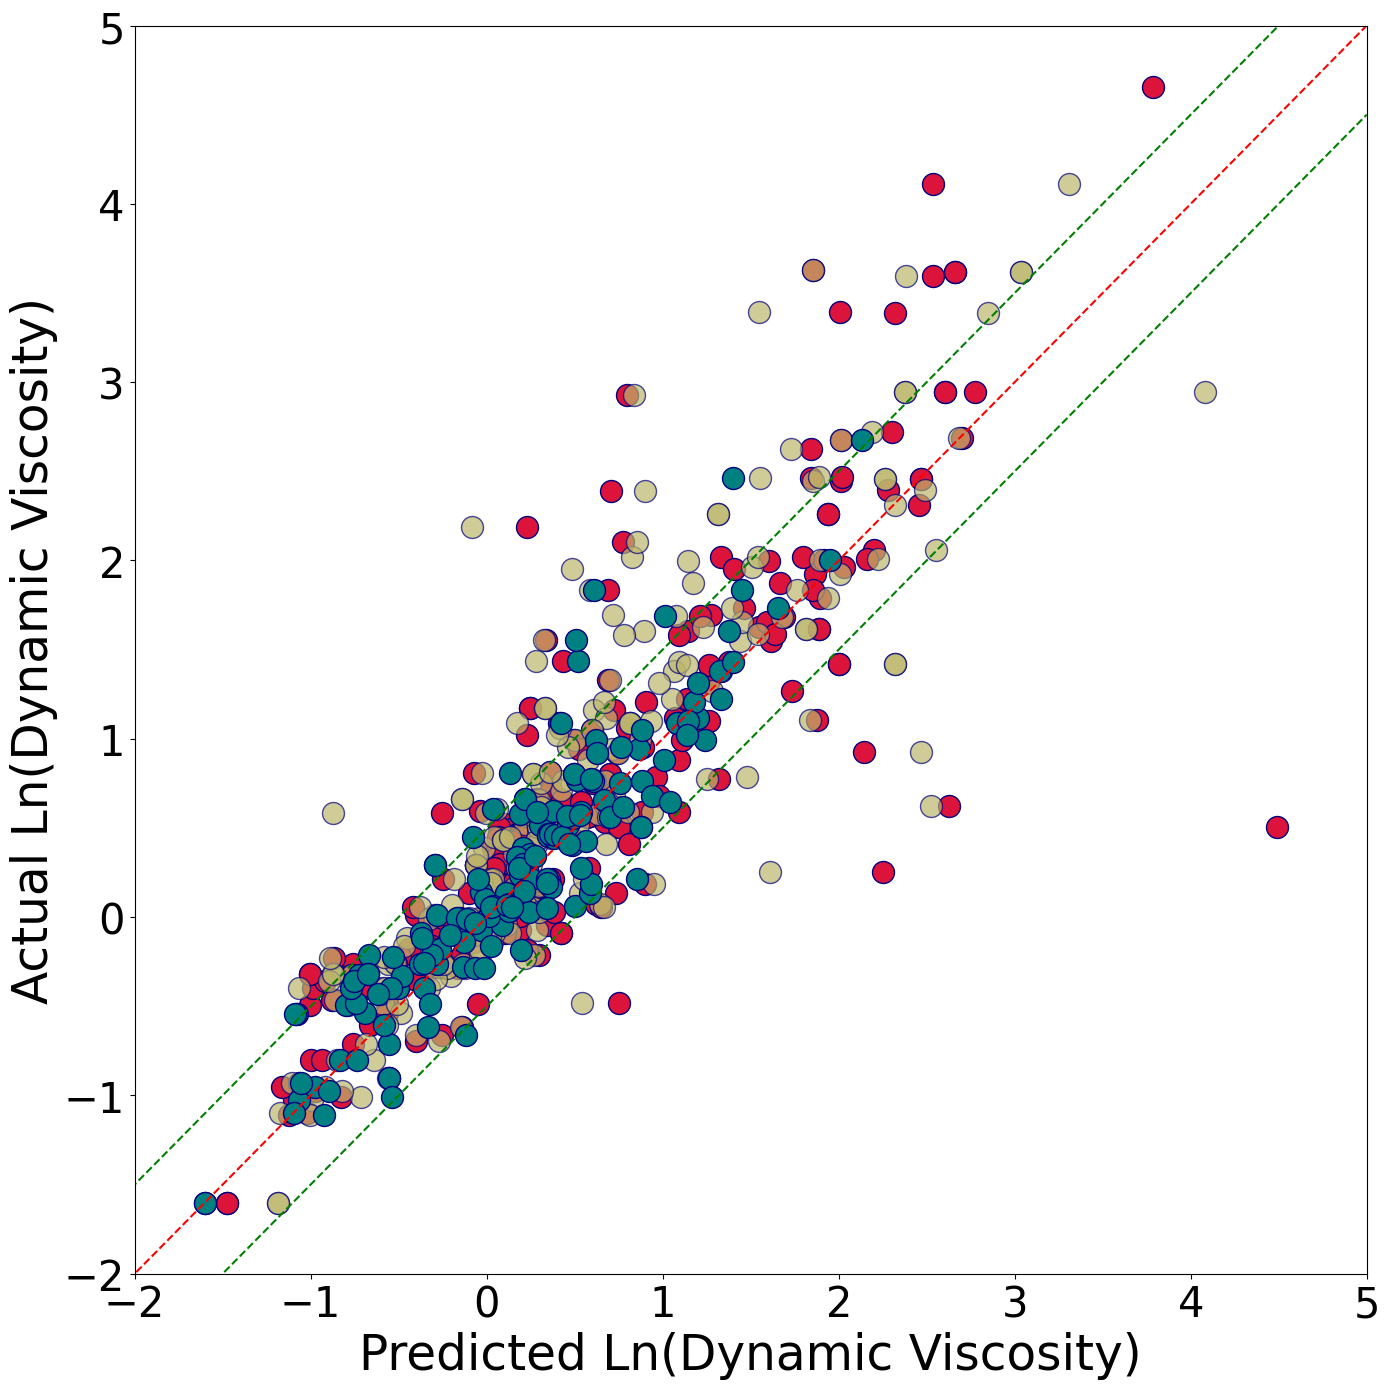

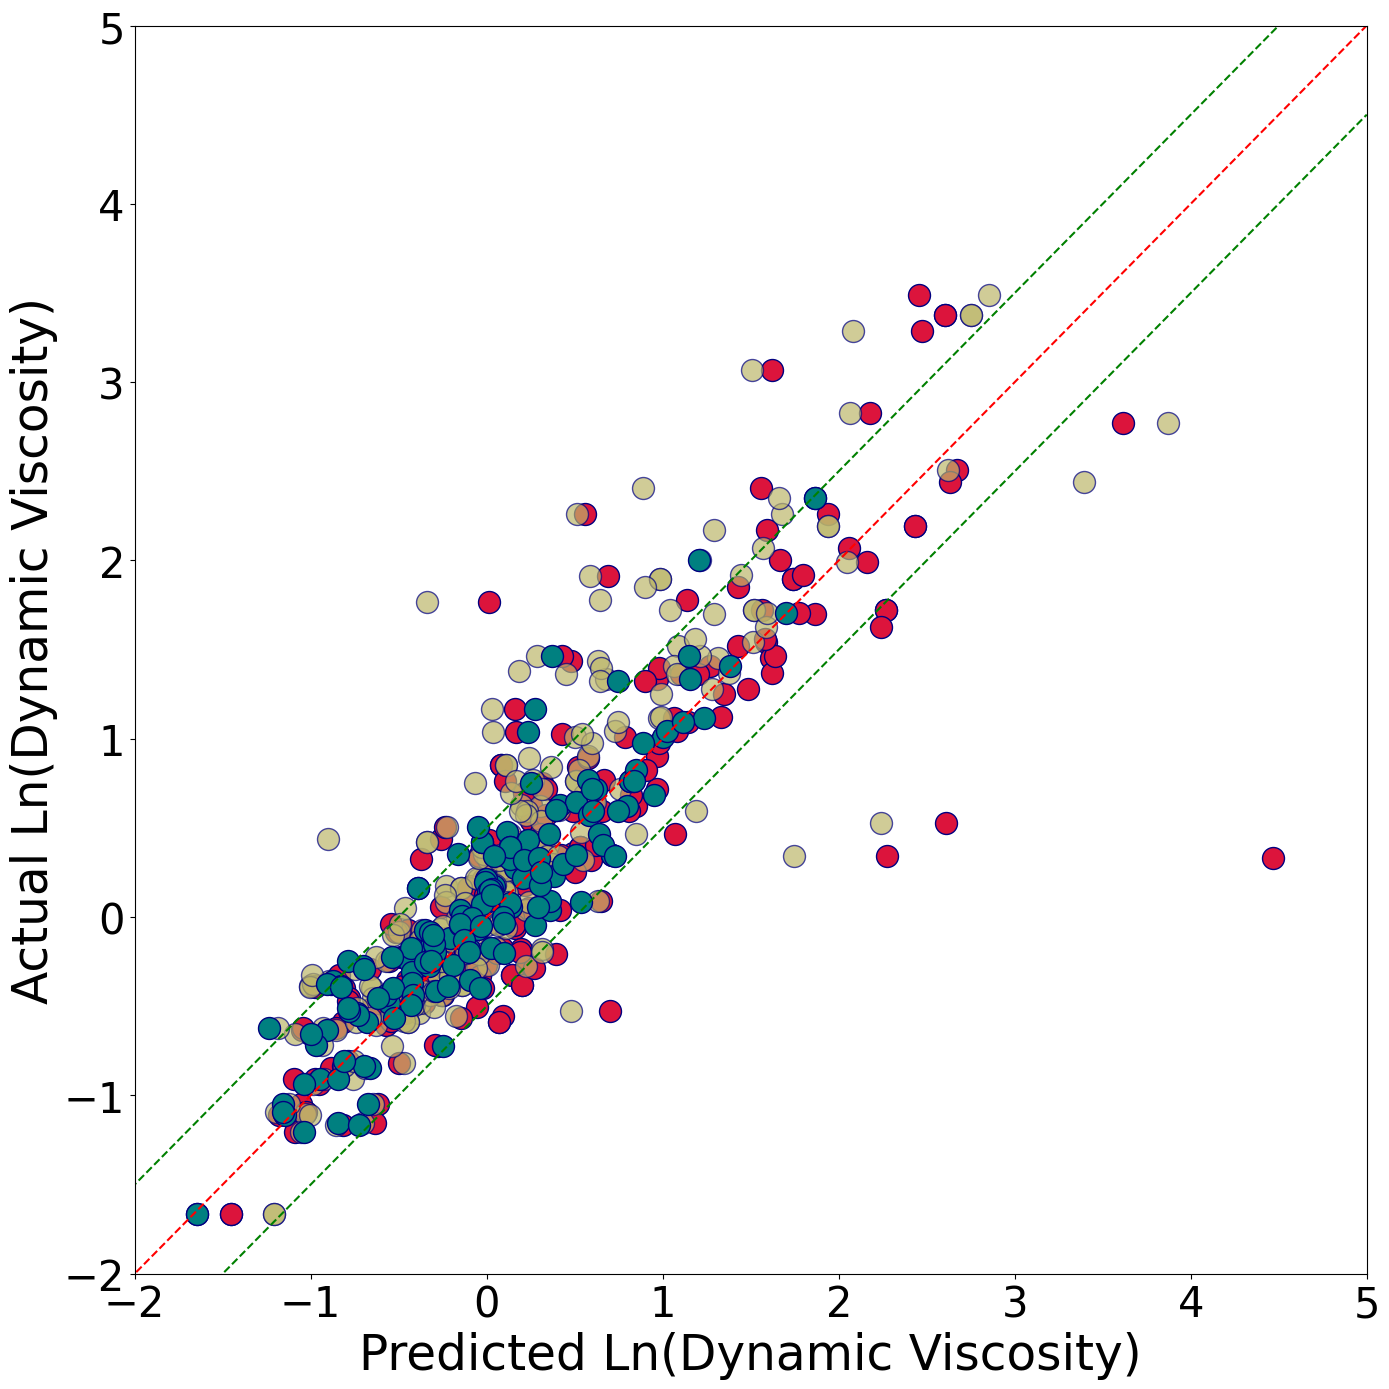

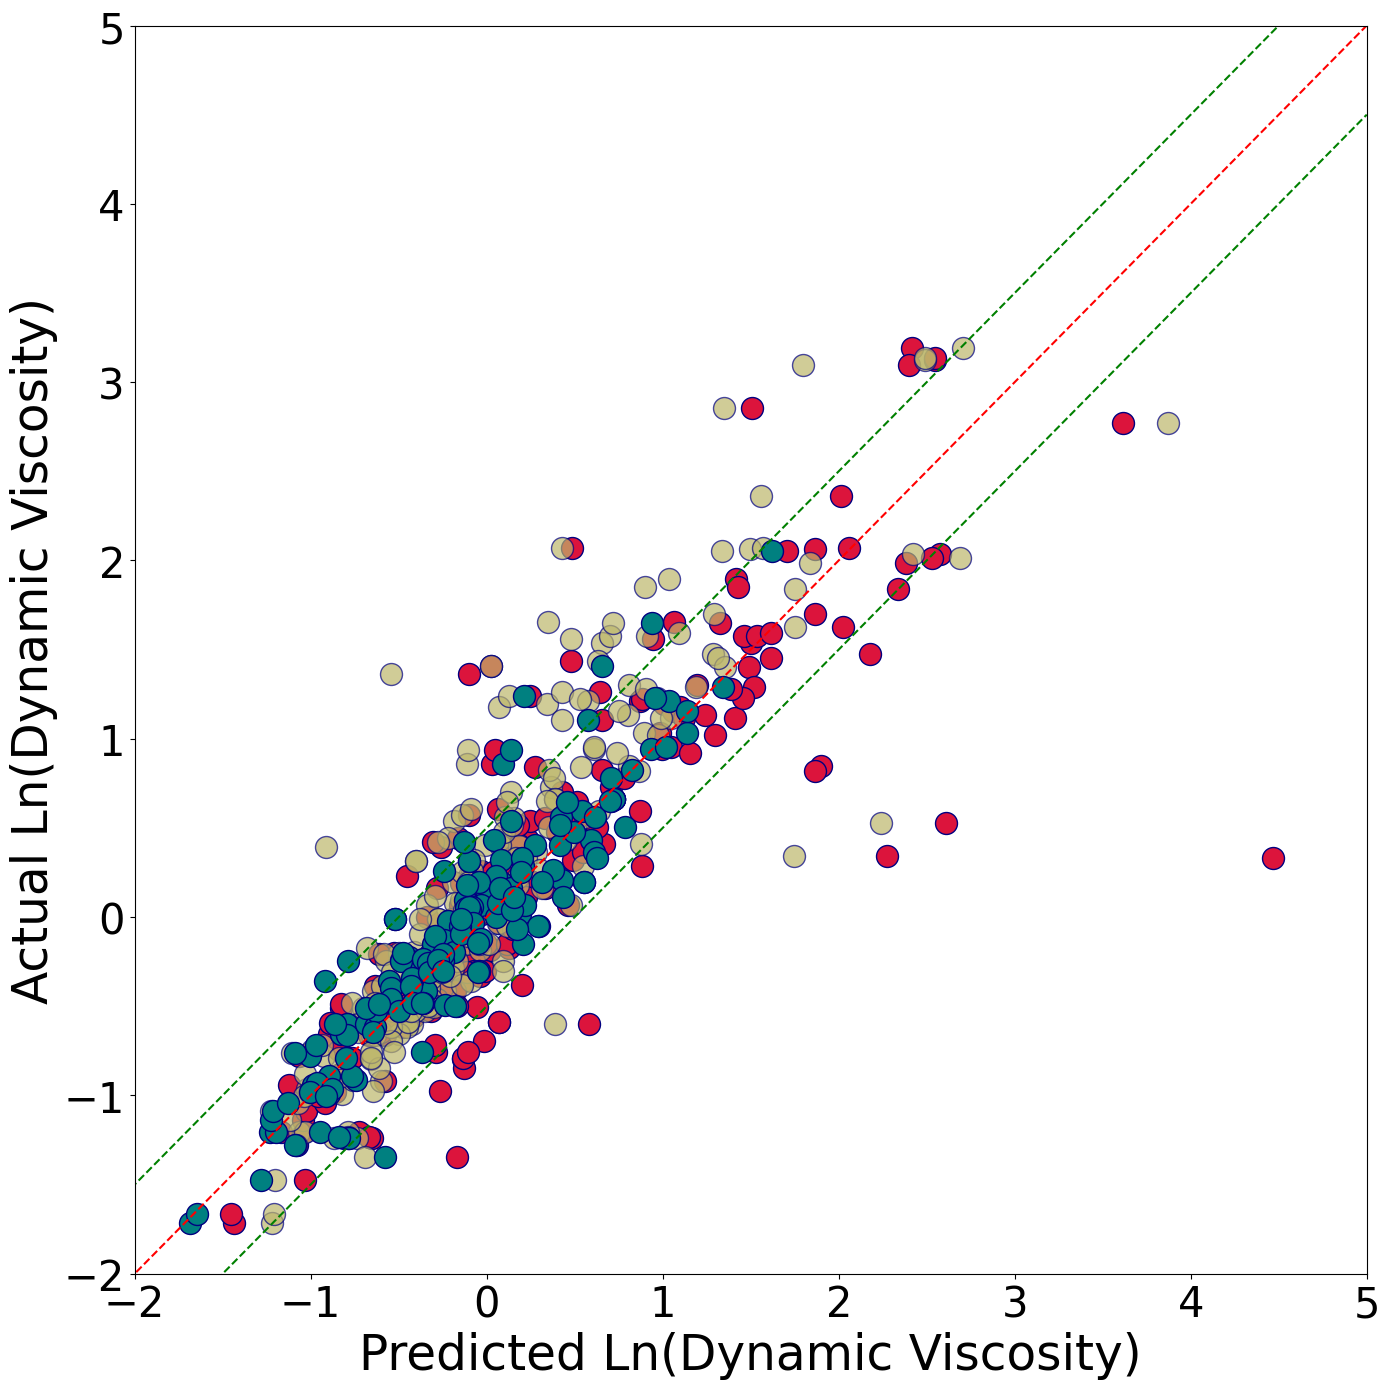

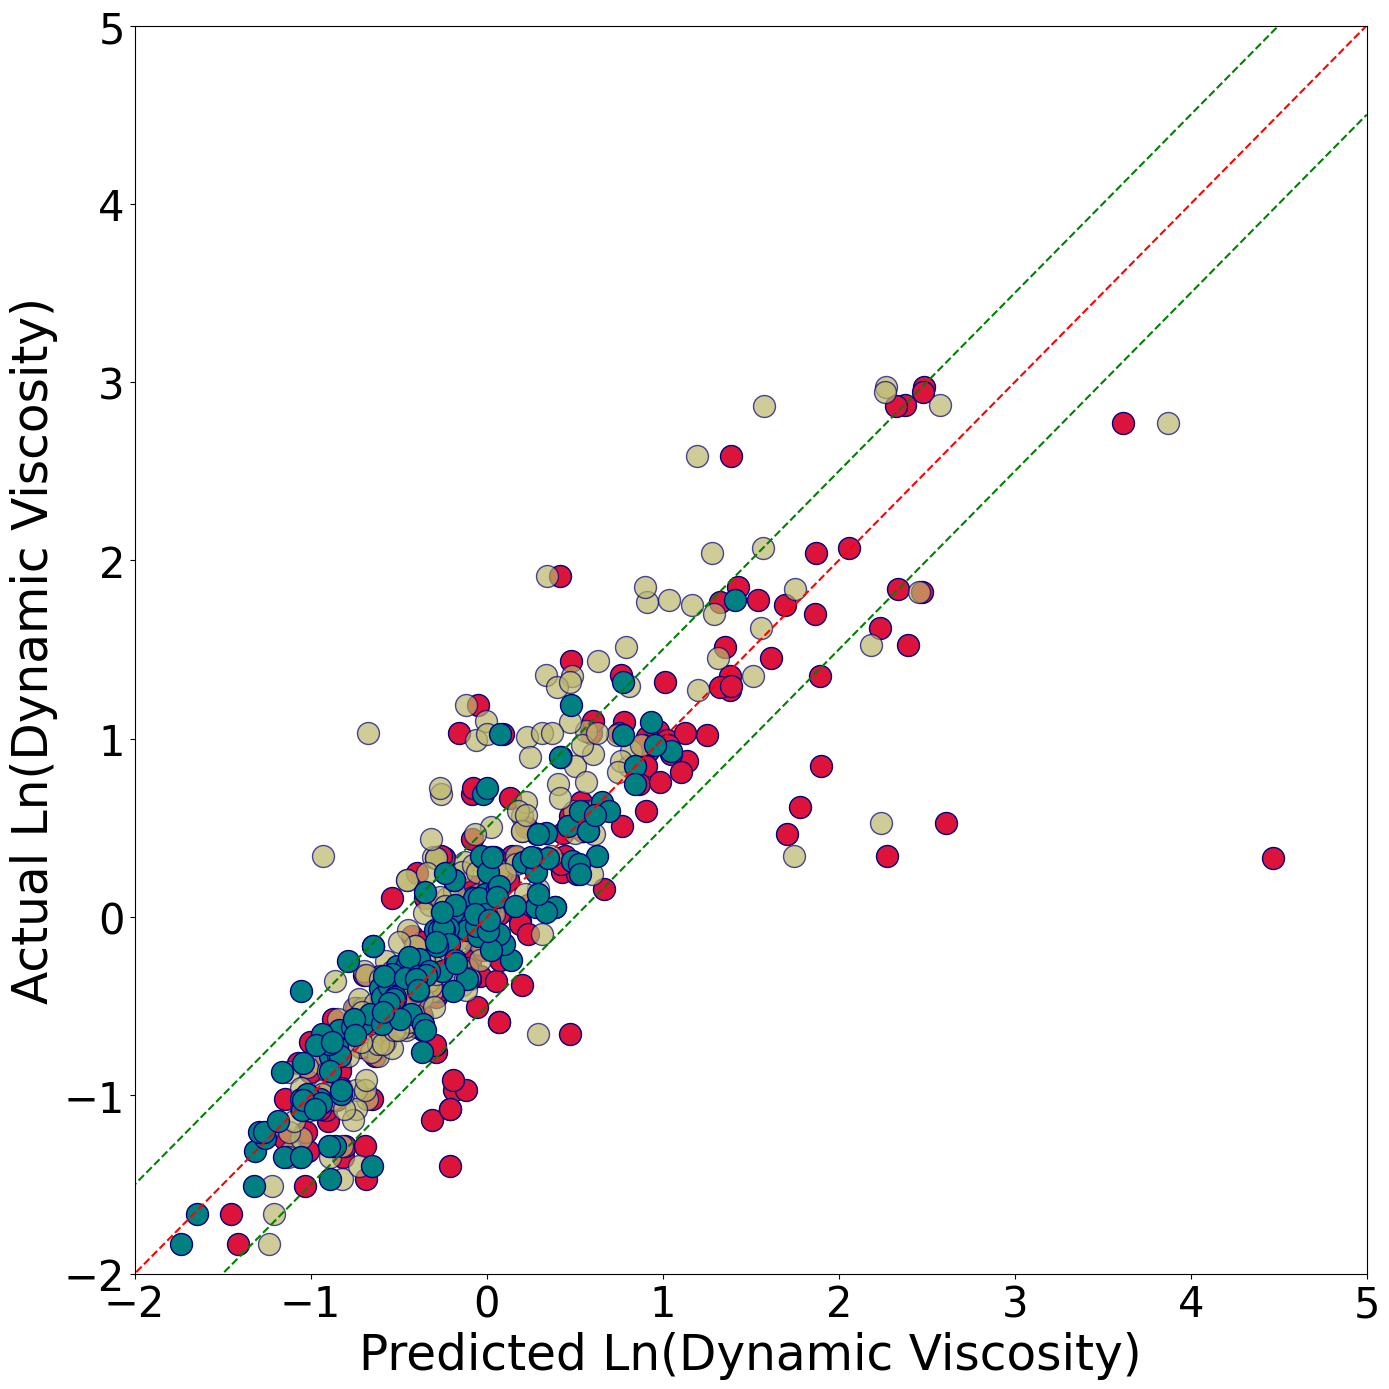

In [6]:
y_test_pred = output[['mu_log_1', 'mu_log_2', 'mu_log_3', 'mu_log_4', 'mu_log_5']]
df_mu_test = pd.read_excel('data/Dataset.xlsx', sheet_name='mu_test')
y_test_true = df_mu_test.iloc[:,1:]

rmse, mae, srcc, r2, mse = {},{},{},{}, {}
rmse_base_all, mae_base_all, srcc_base_all, r2_base_all, mse_base_all = {},{},{},{}, {}
rmse_base_all_singleT, mae_base_all_singleT, srcc_base_all_singleT, r2_base_all_singleT, mse_base_all_singleT = {},{},{},{}, {}


for i in range(5):
    parity_accurate_region_threshold = 0.5
    fig, ax = plt.subplots(figsize=(14, 14))
    
    y_test_pred_certain = y_test_pred.iloc[:,i][output['Ln_A_std'] < 0.6]
    y_test_true_certain = y_test_true.iloc[:,i][output['Ln_A_std'] < 0.6 ]
    compounds_name = output['Compounds'][output['Ln_A_std'] < 0.6]

    
    y_test_pred_certain_base_all = y_pred_base_avg_temp_all.iloc[:,i][y_pred_base_certainty_temp_all[i] == True]
    y_test_true_certain_base_all = y_test_true.iloc[:,i][y_pred_base_certainty_temp_all[i] == True]

    y_test_pred_certain_base_all_singleT = y_pred_base_avg_temp_all_singleT.iloc[:,i][y_pred_base_certainty_temp_all_singleT[i] == True]
    y_test_true_certain_base_all_singleT = y_test_true.iloc[:,i][y_pred_base_certainty_temp_all_singleT[i] == True]
    

    min_val = -3
    max_val = 5
    marker_size = 250
    ax.scatter(y_test_pred_certain_base_all_singleT, y_test_true_certain_base_all_singleT, color='crimson', edgecolor = 'navy', s = marker_size , alpha=1, label='Isothermal base model', zorder = 2)            
    ax.scatter(y_test_pred_certain_base_all, y_test_true_certain_base_all, color='darkkhaki', edgecolor = 'navy', s = marker_size , alpha=0.7, label='Multitemperature base model', zorder = 2)            
    ax.scatter(y_test_pred_certain, y_test_true_certain, color='teal', edgecolor = 'navy', s = marker_size , alpha=1, label='thermoML (Certain)', zorder = 2)
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Fit')


    ax.plot([min_val, max_val], [min_val + parity_accurate_region_threshold, max_val + parity_accurate_region_threshold], 'g--', label='+/- Accuracy Threshold')
    ax.plot([min_val, max_val], [min_val - parity_accurate_region_threshold, max_val - parity_accurate_region_threshold], 'g--')                

    ax.set_ylim(-2,5)
    ax.set_xlim(-2,5)

    ax.set_xlabel('Predicted Ln(Dynamic Viscosity)', fontsize = 35)
    ax.set_ylabel('Actual Ln(Dynamic Viscosity)', fontsize = 35)
    ax.tick_params(axis='x', labelsize=30) 
    ax.tick_params(axis='y', labelsize=30)


    rmse[i] = np.sqrt(((y_test_true_certain - y_test_pred_certain) ** 2).mean())
    mae[i] = (y_test_true_certain - y_test_pred_certain).abs().mean()
    srcc[i], _ = spearmanr(y_test_true_certain, y_test_pred_certain)
    r2[i] = r2_score(y_test_true_certain, y_test_pred_certain)
    mse[i] = ((y_test_true_certain - y_test_pred_certain) ** 2).mean()

    rmse_base_all[i] = np.sqrt(((y_test_pred_certain_base_all - y_test_true_certain_base_all) ** 2).mean())
    mae_base_all[i] = (y_test_pred_certain_base_all- y_test_true_certain_base_all).abs().mean()
    srcc_base_all[i], _ = spearmanr(y_test_pred_certain_base_all, y_test_true_certain_base_all)
    r2_base_all[i] = r2_score(y_test_pred_certain_base_all, y_test_true_certain_base_all)
    mse_base_all[i] = ((y_test_pred_certain_base_all - y_test_true_certain_base_all) ** 2).mean()
    
    rmse_base_all_singleT[i] = np.sqrt(((y_test_pred_certain_base_all_singleT - y_test_true_certain_base_all_singleT) ** 2).mean())
    mae_base_all_singleT[i] = (y_test_pred_certain_base_all_singleT- y_test_true_certain_base_all_singleT).abs().mean()
    srcc_base_all_singleT[i], _ = spearmanr(y_test_pred_certain_base_all_singleT, y_test_true_certain_base_all_singleT)
    r2_base_all_singleT[i] = r2_score(y_test_pred_certain_base_all_singleT, y_test_true_certain_base_all_singleT)    
    mse_base_all_singleT[i] = ((y_test_pred_certain_base_all_singleT - y_test_true_certain_base_all_singleT) ** 2).mean()
    
    plt.tight_layout(rect=[0, 0, 1, 1])
    plt.show()